# 01 — Exploratory Data Analysis & Data Cleaning

**Objective:** Load the raw `CC_GENERAL.csv` dataset, perform thorough
quality checks, clean null values and duplicates, generate EDA
visualisations, and persist the cleaned output for downstream use.

**Pipeline position:** This is the first notebook in the sequence.
It produces `data/processed/cleaned_customers.csv`.

In [1]:
import sys
from pathlib import Path

# Ensure the project root is on sys.path so `src` imports work
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import ensure_directories
ensure_directories()
print(f"Project root: {PROJECT_ROOT}")

Project root: E:\college\Project\Credit card\credit_card_analytics


## 1. Load Raw Data

The dataset contains ~8,950 credit-card customers with 18 columns
covering balance, purchase behaviour, cash advances, and payment history.
`CUST_ID` is set as the index immediately to prevent it from being
treated as a numeric feature.

In [2]:
from src.preprocessing import load_raw_data

raw_df = load_raw_data()
raw_df.head()

  ✓ Raw data loaded: 8950 rows, 17 columns


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# Quick shape and dtype overview before any transformations
print(f"Shape: {raw_df.shape}")
print(f"\nData types:\n{raw_df.dtypes}")
print(f"\nNull counts:\n{raw_df.isnull().sum()}")

Shape: (8950, 17)

Data types:
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Null counts:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES           

## 2. Data Cleaning

Cleaning steps applied:
1. **MINIMUM_PAYMENTS** — impute nulls with the column *median*
   (not mean — distribution is heavily right-skewed).
2. **CREDIT_LIMIT** — drop the ~1 row with a null (negligible loss).
3. **Duplicates** — remove any exact duplicate rows.
4. **Data types** — cast all financial columns to `float64`.

In [4]:
from src.preprocessing import clean_data, print_quality_report

cleaned_df, nulls_before, nulls_after, shape_before = clean_data(raw_df)
print_quality_report(cleaned_df, nulls_before, nulls_after, shape_before)

  ✓ MINIMUM_PAYMENTS nulls imputed with median (₹312.34)
  ✓ Dropped 1 row(s) with null CREDIT_LIMIT
  ✓ Removed 0 exact duplicate row(s)
  ✓ All financial columns cast to float64
  ✓ Cleaning complete: 8950 → 8949 rows retained

  DATA QUALITY REPORT

  Shape before cleaning : (8950, 17)
  Shape after cleaning  : (8949, 17)

  ── Null Counts ──
                                  Before  After
BALANCE                                0      0
BALANCE_FREQUENCY                      0      0
PURCHASES                              0      0
ONEOFF_PURCHASES                       0      0
INSTALLMENTS_PURCHASES                 0      0
CASH_ADVANCE                           0      0
PURCHASES_FREQUENCY                    0      0
ONEOFF_PURCHASES_FREQUENCY             0      0
PURCHASES_INSTALLMENTS_FREQUENCY       0      0
CASH_ADVANCE_FREQUENCY                 0      0
CASH_ADVANCE_TRX                       0      0
PURCHASES_TRX                          0      0
CREDIT_LIMIT                

E:\college\Project\Credit card\credit_card_analytics\src\preprocessing.py:86: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe["MINIMUM_PAYMENTS"].fillna(median_min_payments, inplace=True)


## 3. Save Cleaned Data

Persist the cleaned dataframe to `data/processed/cleaned_customers.csv`
so that subsequent notebooks can load it without re-running this one.

In [5]:
from src.preprocessing import save_cleaned_data

save_cleaned_data(cleaned_df)

  ✓ Cleaned data saved → data\processed\cleaned_customers.csv


## 4. EDA Visualisations

Four plots are generated and saved to `outputs/plots/`:

| # | Plot | Purpose |
|---|------|---------|
| 1 | Distribution histograms (4×5) | Identify skew and modality |
| 2 | Correlation heatmap | Spot multicollinearity |
| 3 | Box plots | Quantify outlier spread |
| 4 | Purchases vs Credit Limit | Spending vs capacity relationship |

In [6]:
from src.preprocessing import (
    plot_distributions,
    plot_correlation_heatmap,
    plot_outlier_boxplots,
    plot_purchases_vs_credit_limit,
)

plot_distributions(cleaned_df)
plot_correlation_heatmap(cleaned_df)
plot_outlier_boxplots(cleaned_df)
plot_purchases_vs_credit_limit(cleaned_df)

  ✓ Distribution histograms saved → 01_feature_distributions.png
  ✓ Correlation heatmap saved → 02_correlation_heatmap.png
  ✓ Outlier boxplots saved → 03_outlier_boxplots.png
  ✓ Scatter plot saved → 04_purchases_vs_credit_limit.png


### 4.1 — Display Generated Plots

Load and render the saved PNG files inline for notebook review.


────────────────────────────────────────────────────────────
  01_feature_distributions.png
────────────────────────────────────────────────────────────


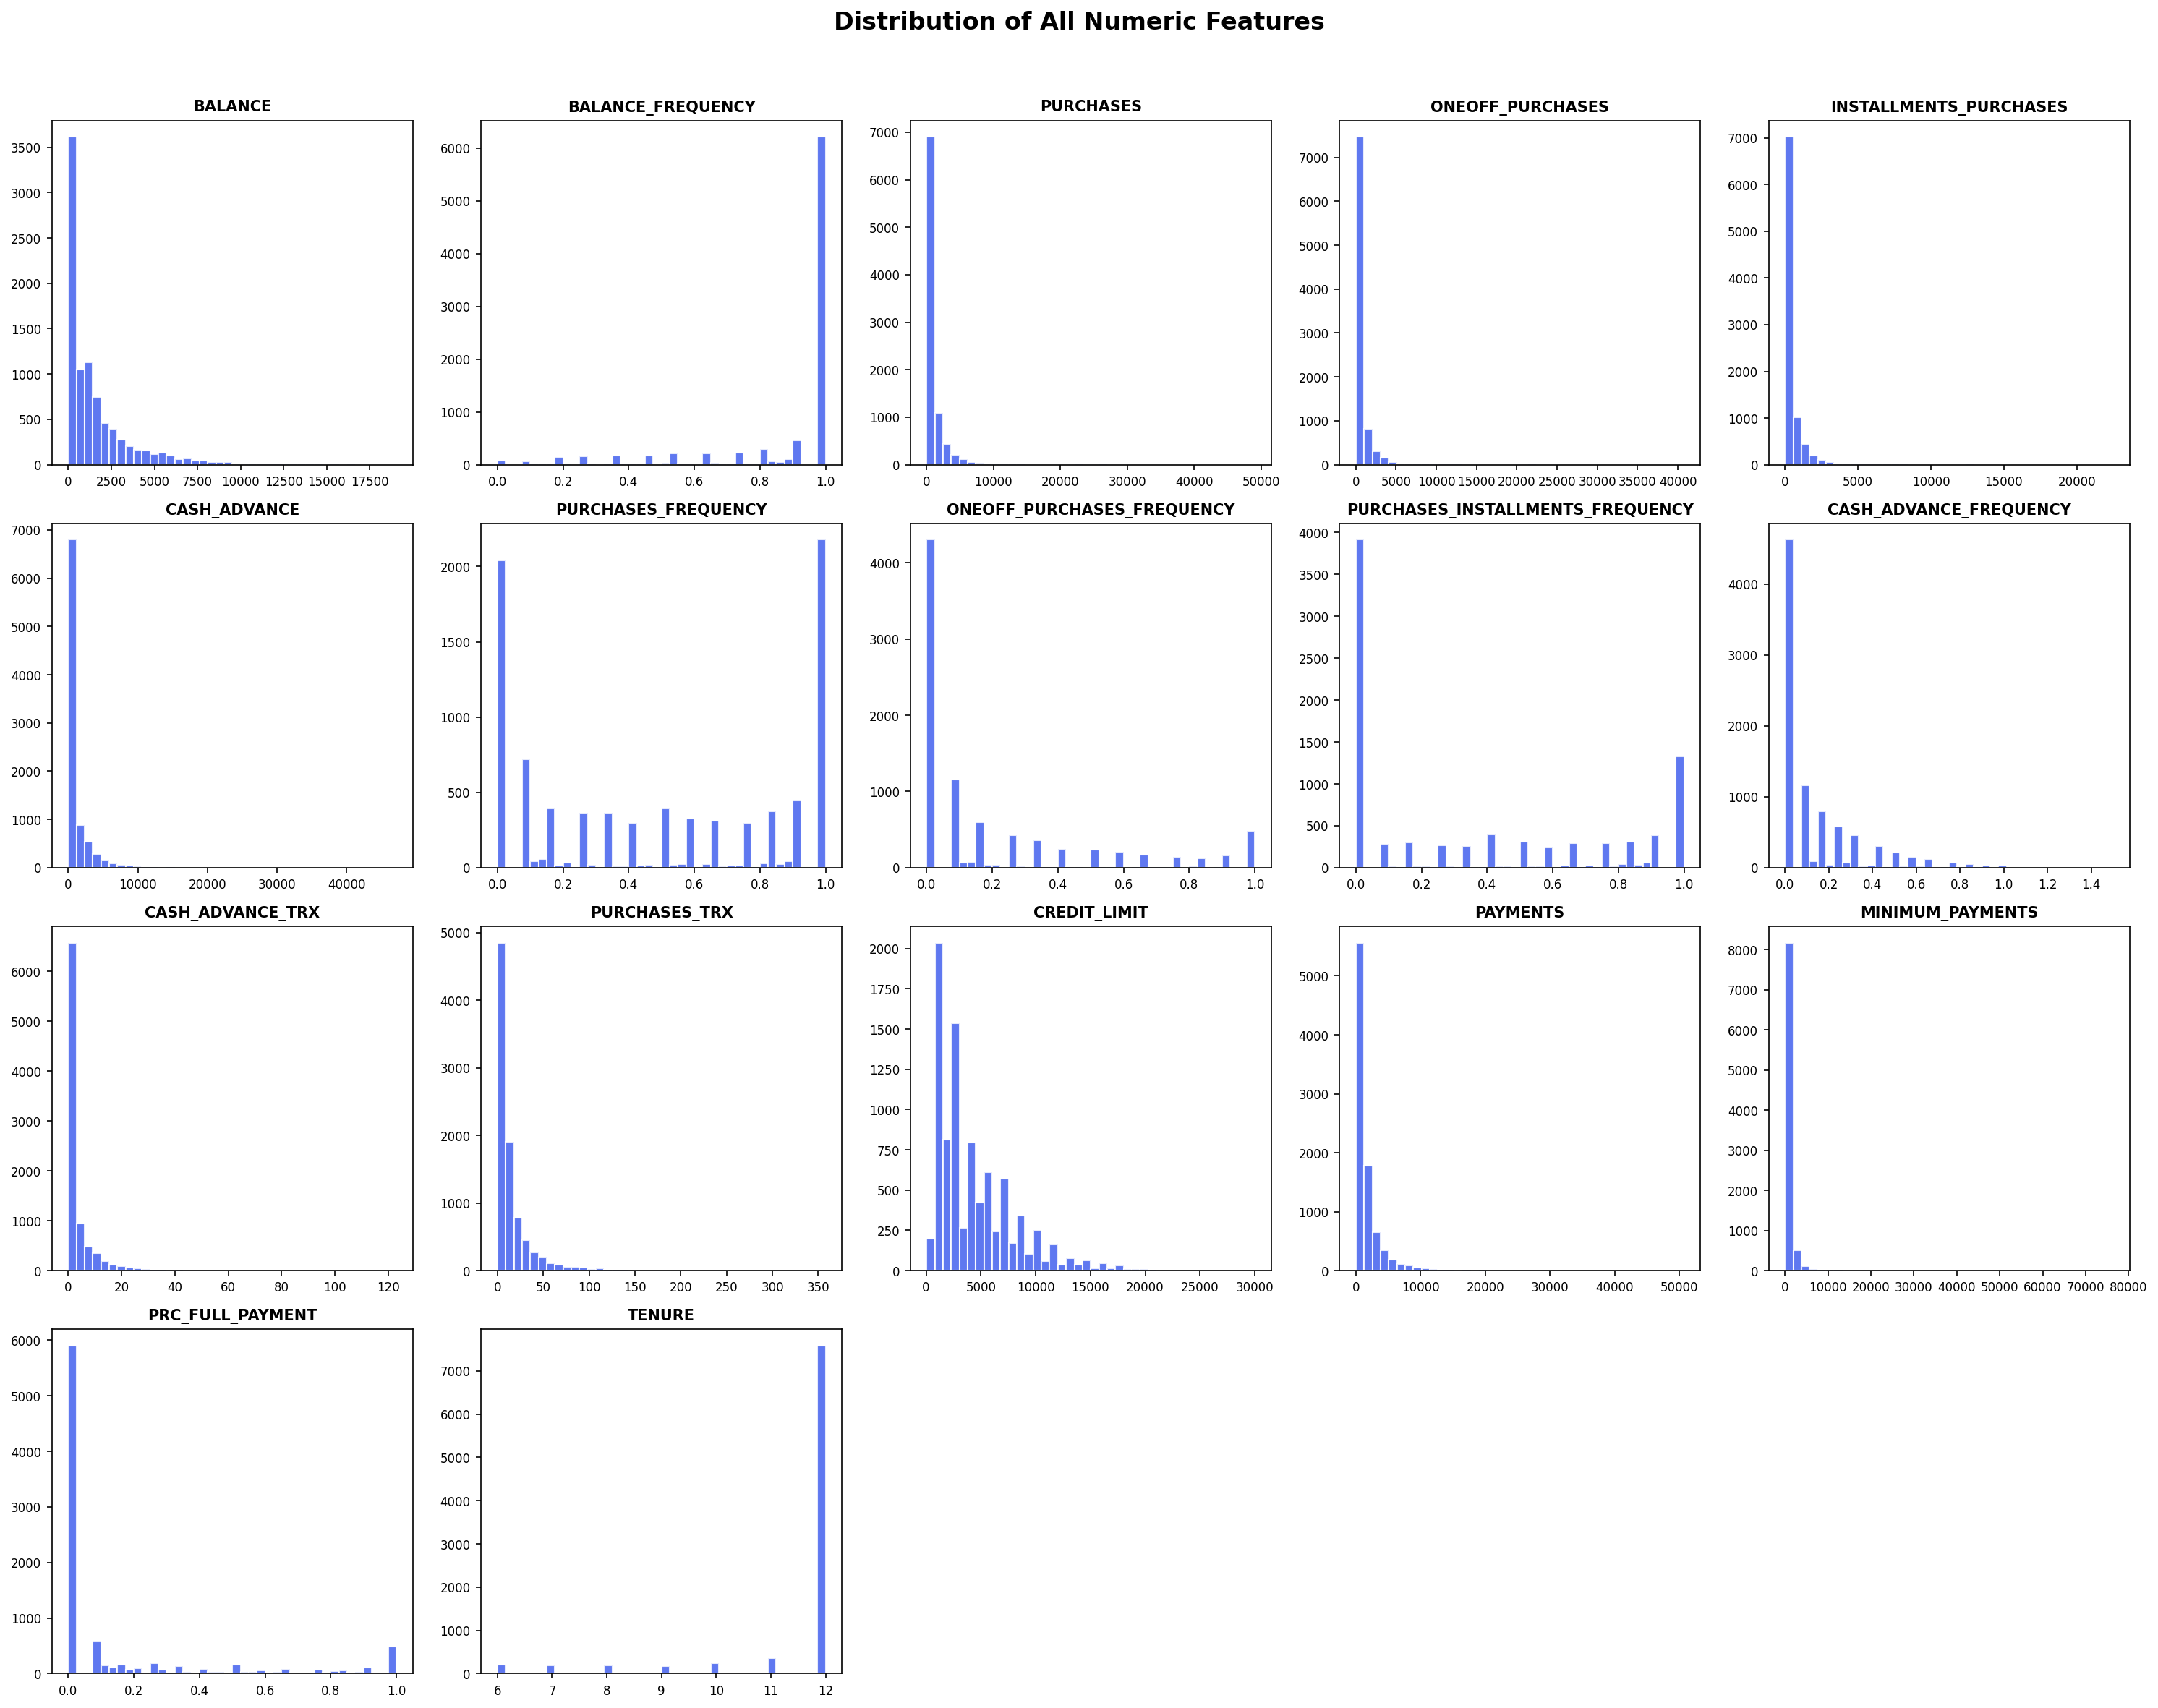


────────────────────────────────────────────────────────────
  02_correlation_heatmap.png
────────────────────────────────────────────────────────────


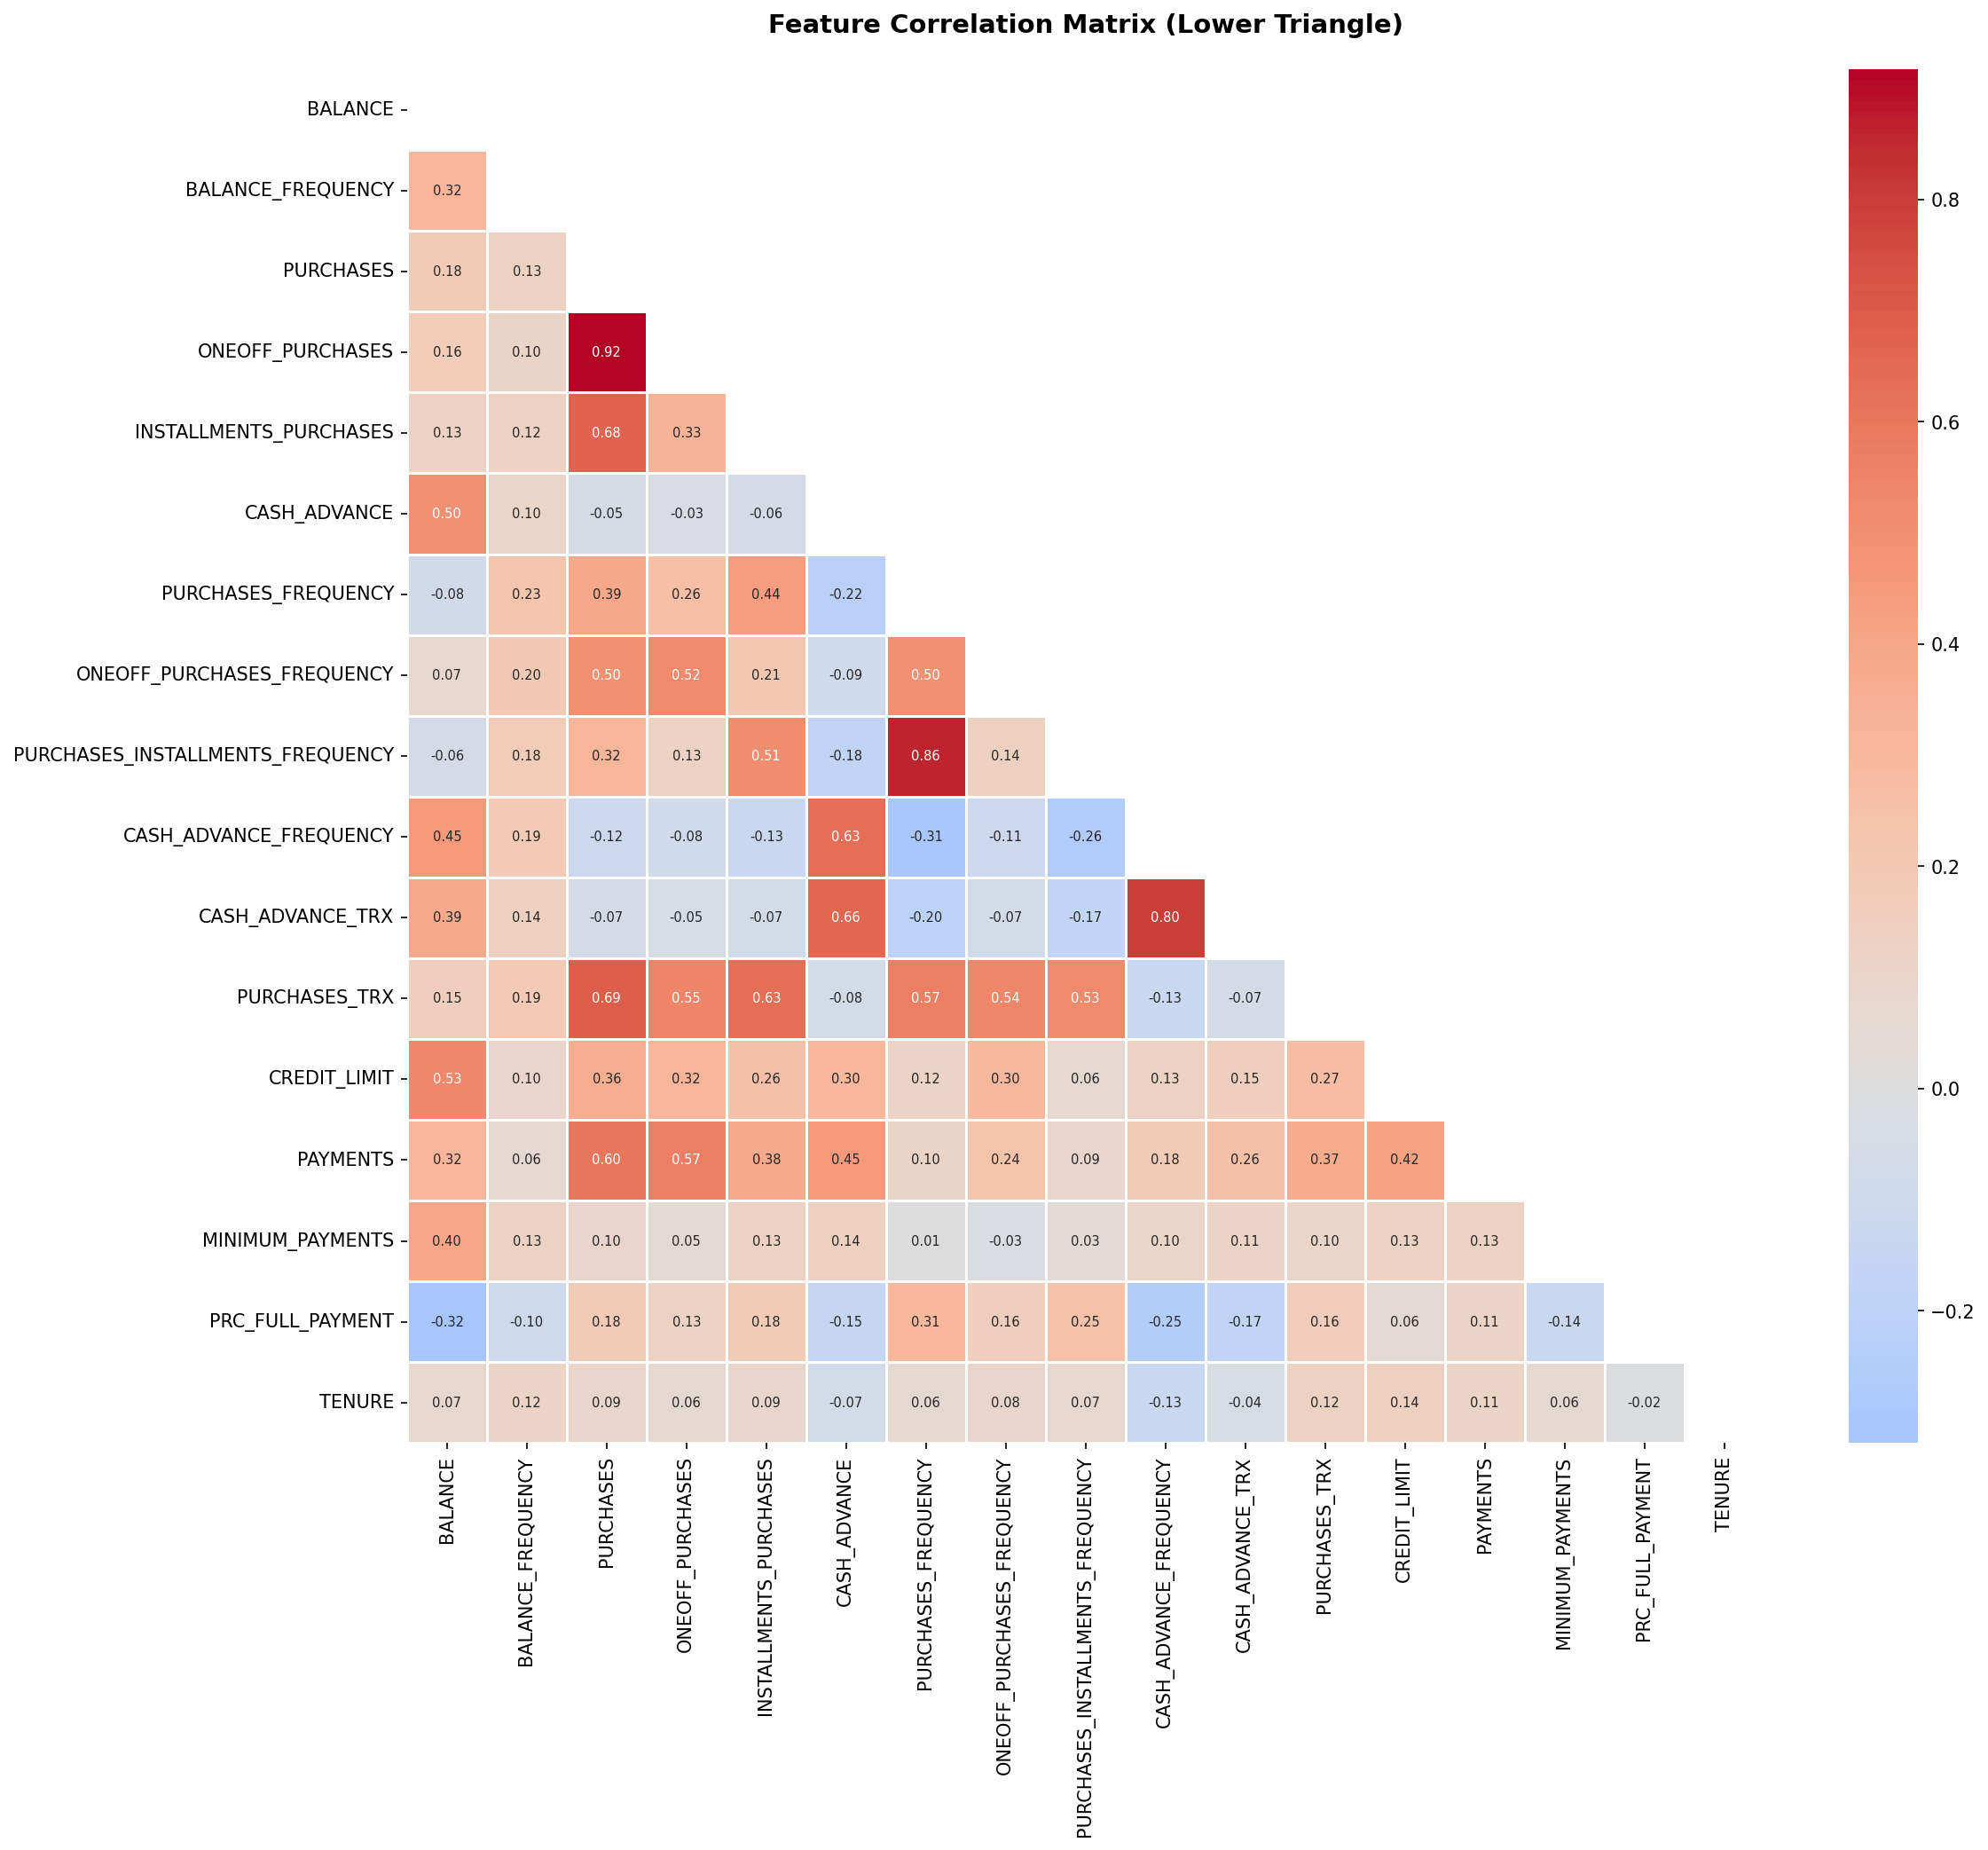


────────────────────────────────────────────────────────────
  03_outlier_boxplots.png
────────────────────────────────────────────────────────────


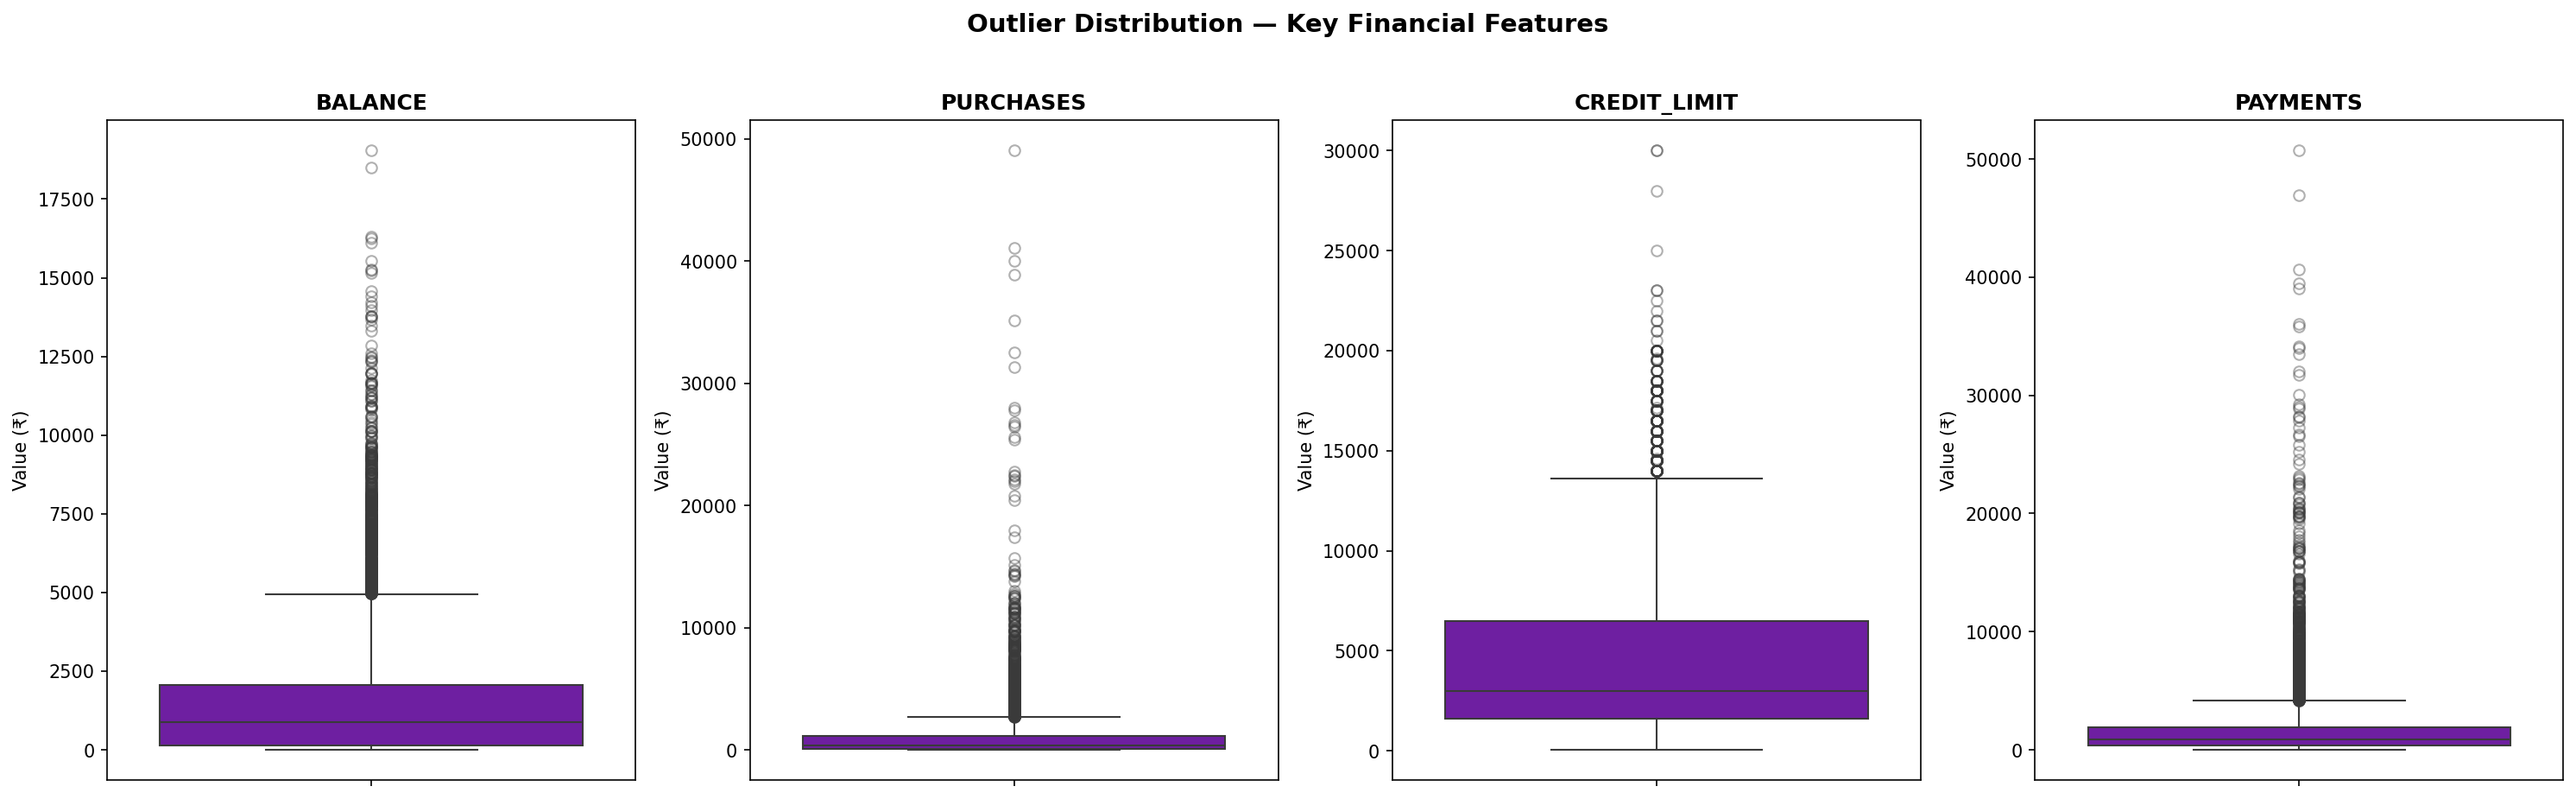


────────────────────────────────────────────────────────────
  04_purchases_vs_credit_limit.png
────────────────────────────────────────────────────────────


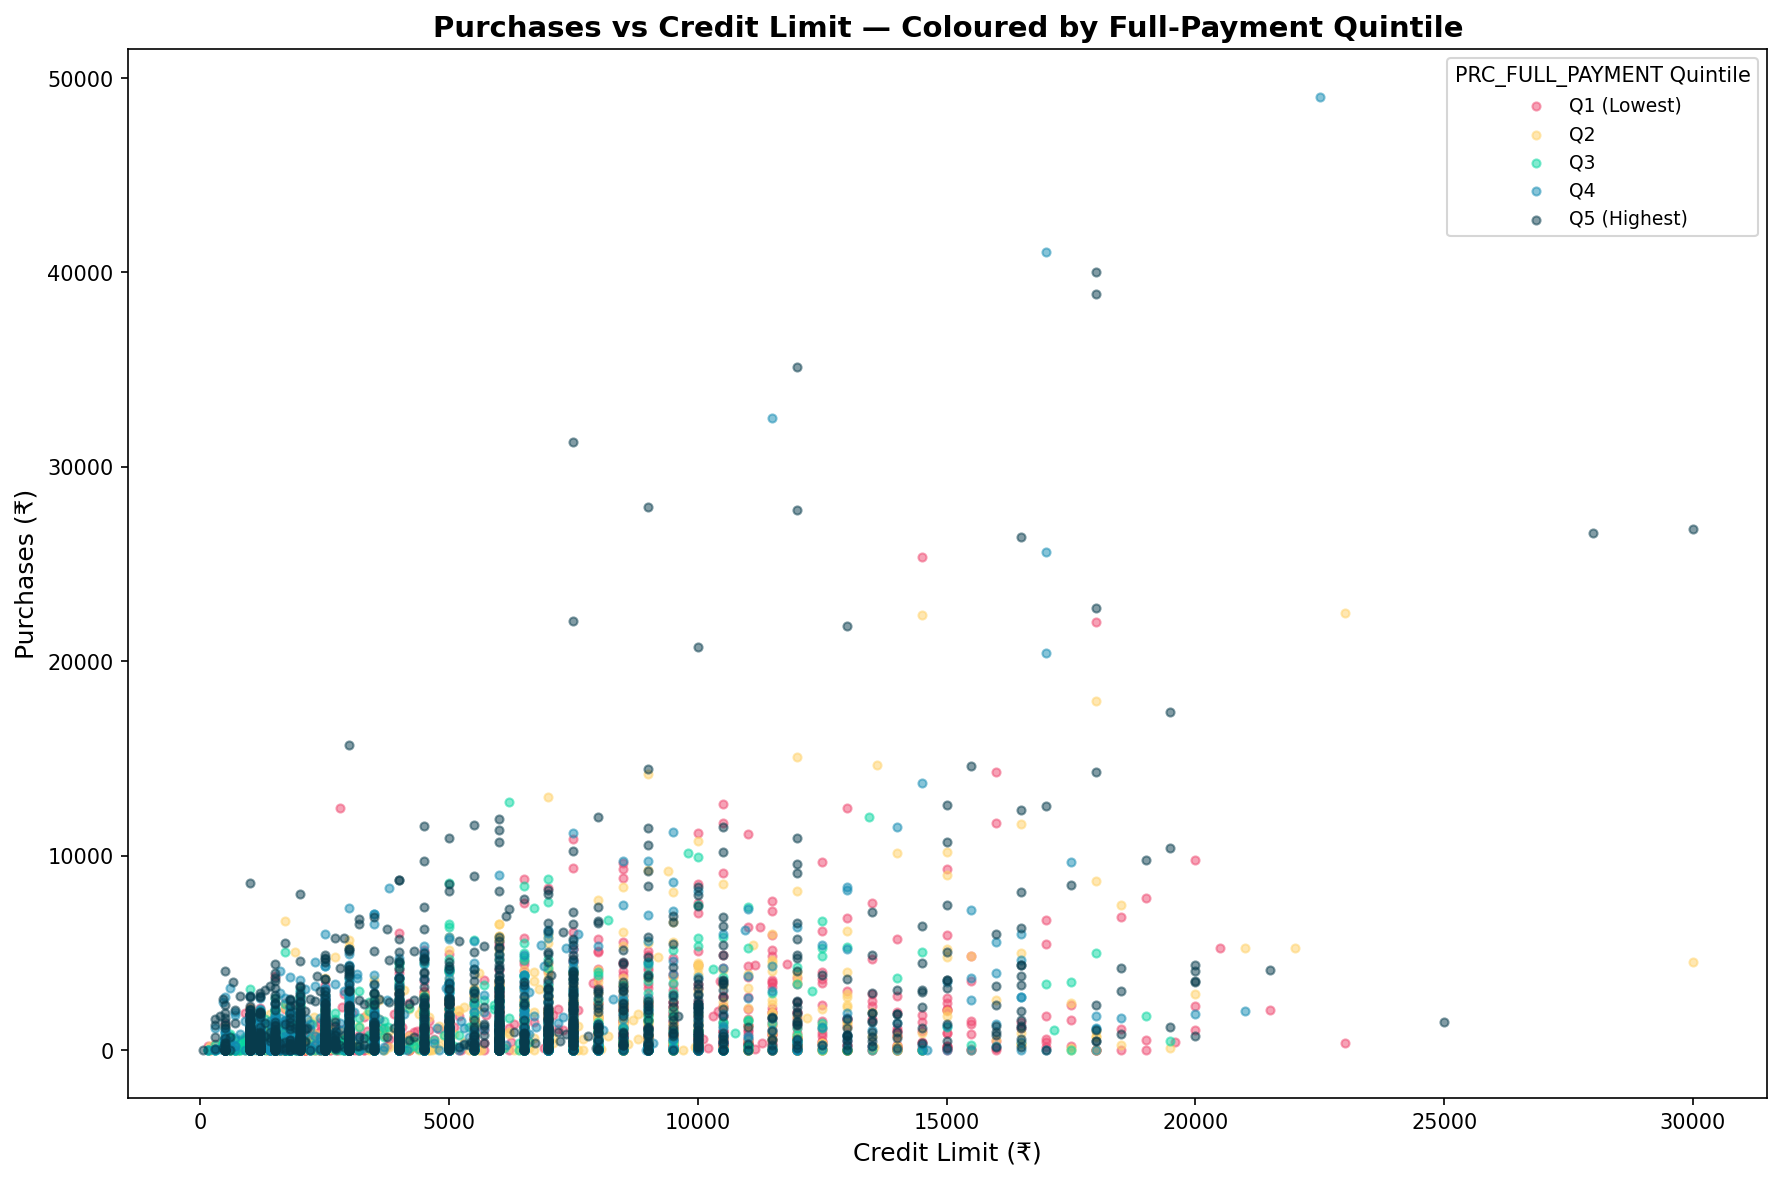

In [7]:
from IPython.display import Image, display
from src.utils import PLOTS_DIR

for plot_file in sorted(PLOTS_DIR.glob("0[1-4]_*.png")):
    print(f"\n{'─' * 60}")
    print(f"  {plot_file.name}")
    print(f"{'─' * 60}")
    display(Image(filename=str(plot_file), width=900))

## 5. Key Observations

- Most financial features (BALANCE, PURCHASES, CASH_ADVANCE) are
  **heavily right-skewed**, confirming that median imputation was the
  correct choice for MINIMUM_PAYMENTS.
- **PURCHASES and ONEOFF_PURCHASES** show strong positive correlation
  (r ≈ 0.92), which is expected — one-off purchases are a component of
  total purchases.
- **Outlier spread** in BALANCE and CASH_ADVANCE is substantial; these
  customers will likely form distinct clusters and may surface as anomalies.
- The scatter plot reveals that customers with **high credit limits but
  low purchases** (bottom-right quadrant) are potential dormant accounts.

---
*Next: [02_Feature_Engineering.ipynb](02_Feature_Engineering.ipynb) →
derive 6 behavioural ratios from the cleaned data.*